In [1]:
import pm4py
import os
import cProfile
import re
import numpy as np

from pm4py.pm4py.objects.petri_net.utils.petri_utils import construct_trace_net_cost_aware
from pm4py.pm4py.objects.petri_net.utils.synchronous_product import construct_cost_aware
from pm4py.pm4py.objects.petri_net.utils.incidence_matrix import construct as inc_mat_construct
from pm4py.pm4py.objects.petri_net.utils.consumption_matrix import construct as cons_mat_construct
from pm4py.pm4py.objects.petri_net.utils import align_utils
from pm4py.pm4py.util.lp import solver as lp_solver
from pm4py.pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.pm4py.objects.petri_net.importer import importer as petri_importer
from pm4py.pm4py.visualization.petri_net import visualizer as pn_visualizer
import time, os
from pm4py.pm4py.algo.conformance.alignments.petri_net import algorithm as alignments_algorithm
from pm4py.pm4py.algo.conformance.alignments.petri_net.algorithm import Variants as AlignmentsVariants
from pm4py.pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.pm4py.objects.petri_net.importer import importer as petri_importer
from pm4py.pm4py.discovery import discover_petri_net_inductive as inductive_miner

In [2]:

# Load an eventlog from the BPI Challenge 2013 dataset
log_path1 = "data/c2c3b154-ab26-4b31-a0e8-8f2350ddac11/BPI_Challenge_2013_closed_problems.xes"
log_bpi_2012 = xes_importer.apply(log_path1)
print("Number of traces in the eventlog:", len(log_bpi_2012))

# pick a trace
trace_to_align = log_bpi_2012[529]
activity_key = pm4py.util.xes_constants.DEFAULT_NAME_KEY
trace_activities = [event[activity_key] for event in trace_to_align]
print(f"Selected Trace (Case ID: {trace_to_align.attributes.get('concept:name', 'N/A')}):")
print(trace_activities)



/Users/felix/Desktop/Local/Uni/WS26/PPM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 1487/1487 [00:00<00:00, 6016.61it/s]

Number of traces in the eventlog: 1487
Selected Trace (Case ID: 1-578831063):
['Accepted', 'Queued', 'Accepted', 'Accepted', 'Accepted', 'Completed']


Trace cost function: [10000, 10000, 10000, 10000, 10000, 10000]
Vizualizing the chosen Trace Net, reconstructed as a 'mini' Petri Net:


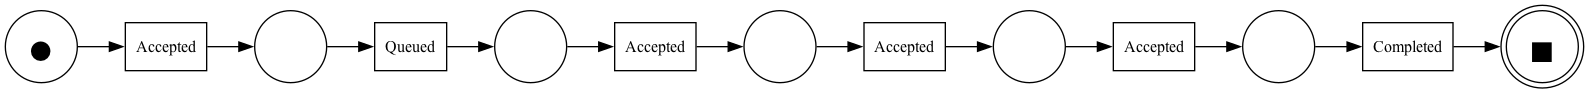

In [3]:
# Build the trace cost functions
# 1. Trace cost function: 1 for every activity in the trace
trace_cost_function = [align_utils.STD_MODEL_LOG_MOVE_COST] * len(trace_to_align)
print("Trace cost function:", trace_cost_function)
# 2. Build the Trace Net
# This creates a simple Petri net that just represents the trace
(
    trace_net,
    trace_im,
    trace_fm,
    trace_net_costs,
) = construct_trace_net_cost_aware(
    trace_to_align, trace_cost_function, activity_key=activity_key
)

# Visualize the trace net
print("Vizualizing the chosen Trace Net, reconstructed as a 'mini' Petri Net:")
trace_to_align_viz = pn_visualizer.apply(trace_net, trace_im, trace_fm)
pn_visualizer.view(trace_to_align_viz)

Vizualizing the discovered process model Petri Net:


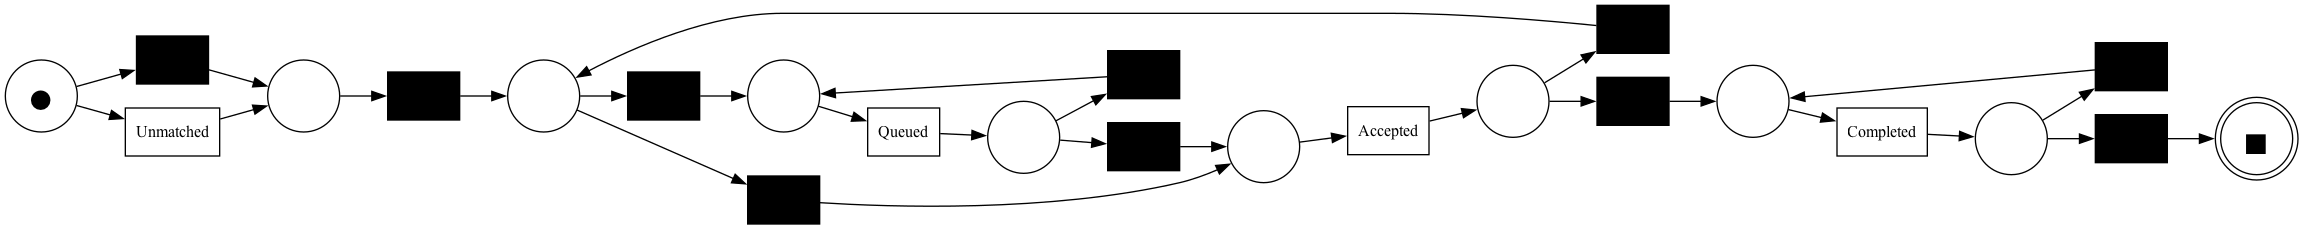

In [4]:
# Discover a process model from the eventlog using the Inductive Miner
model_net, model_im, model_fm = inductive_miner(log_bpi_2012, disable_fallthroughs=False, noise_threshold=0.35)

model_cost_function = {}
for t in model_net.transitions:
    if t.label is not None:
        # This is a "model move"
        model_cost_function[t] = align_utils.STD_MODEL_LOG_MOVE_COST # (which is 10000)
    else:
        # This is a "tau" (silent) move
        model_cost_function[t] = align_utils.STD_TAU_COST # (which is 1)

#print("Model cost function:", model_cost_function)
print("Vizualizing the discovered process model Petri Net:")
model_viz = pn_visualizer.apply(model_net, model_im, model_fm, log=log_bpi_2012)
pn_visualizer.view(model_viz)

In [5]:
sync_cost_function = {}
for t in model_net.transitions:
    if t.label is not None:
        sync_cost_function[t] = align_utils.STD_SYNC_COST # (which is 0)


revised_sync = {}
for t_trace in trace_net.transitions:
    for t_model in model_net.transitions:
        if t_trace.label == t_model.label:
            revised_sync[(t_trace, t_model)] = sync_cost_function.get(t_model, 0)

# This is the "map" A* will search!
sync_prod, sync_initial_marking, sync_final_marking, cost_function = (
    construct_cost_aware(
        trace_net,
        trace_im,
        trace_fm,
        model_net,
        model_im,
        model_fm,
        align_utils.SKIP,
        trace_net_costs,
        model_cost_function,
        revised_sync,
    )
)

print("--- Synchronous Product Net (SPN) ---")
print(f"Original Net Places: {len(model_net.places)}, Transitions: {len(model_net.transitions)}")
print(f"Trace Net Places: {len(trace_net.places)}, Transitions: {len(trace_net.transitions)}")
print(f"SPN Places: {len(sync_prod.places)}, Transitions: {len(sync_prod.transitions)}")




--- Synchronous Product Net (SPN) ---
Original Net Places: 10, Transitions: 14
Trace Net Places: 7, Transitions: 6
SPN Places: 17, Transitions: 26


Viszalizing the constructed Synchronous Product Net (SPN):


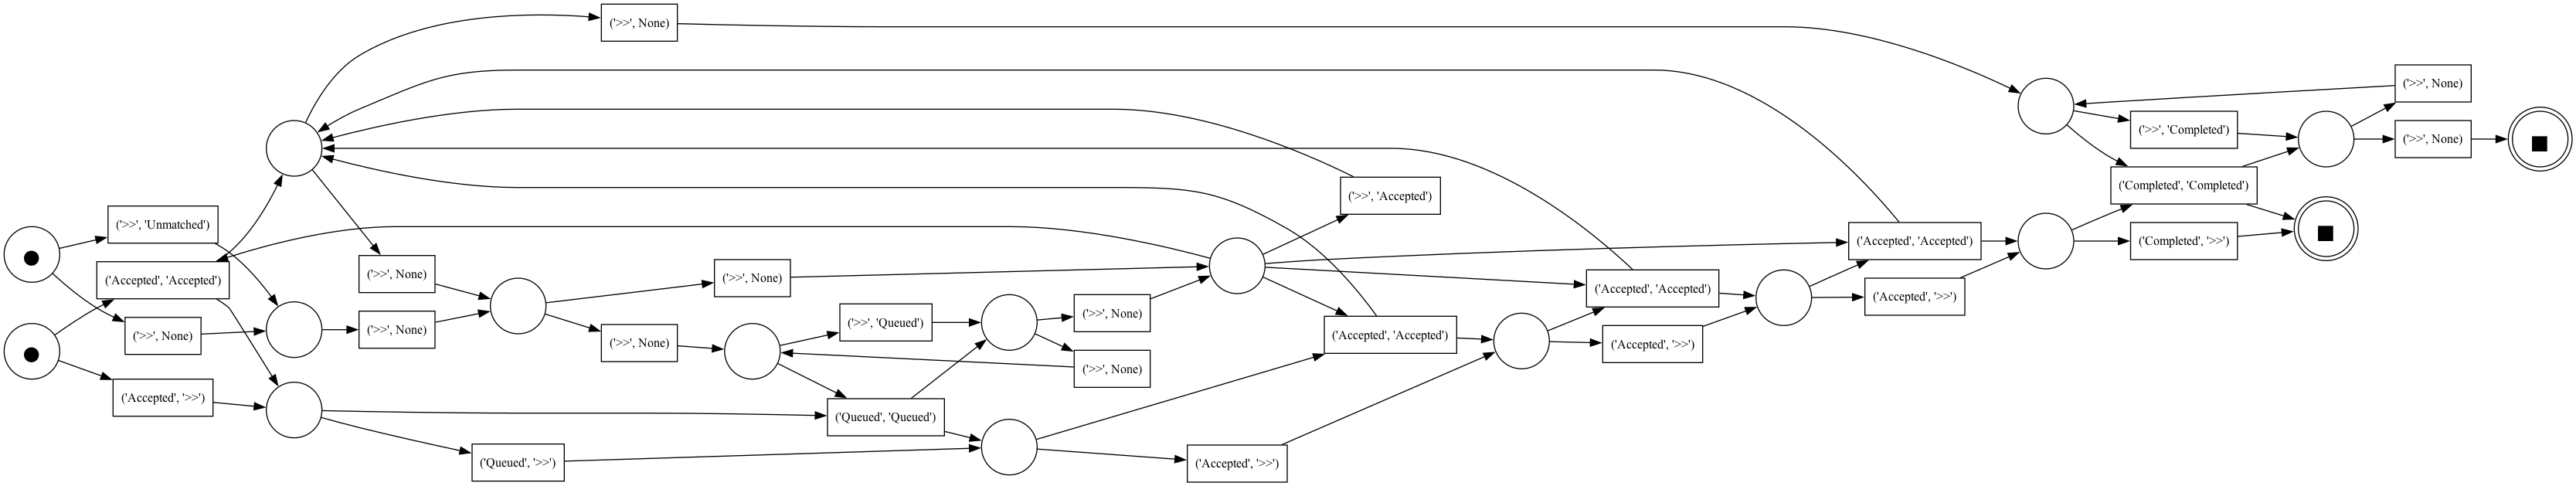

In [6]:
print("Viszalizing the constructed Synchronous Product Net (SPN):")
spn_viz = pn_visualizer.apply(sync_prod, sync_initial_marking, sync_final_marking)
pn_visualizer.view(spn_viz)

In [7]:
candidates = {
    "1. Dijkstra (h=0)": AlignmentsVariants.VERSION_DIJKSTRA_NO_HEURISTICS,
    "2. Remaining Trace": AlignmentsVariants.VERSION_REMAINING_TRACE,
    "3. LP-Heuristic": AlignmentsVariants.VERSION_STATE_EQUATION_A_STAR,
    "4. ILP-Heuristic": AlignmentsVariants.VERSION_STATE_EQUATION_A_STAR_ILP,
    "5. Incremental A*": AlignmentsVariants.VERSION_INCREMENTAL_A_STAR,

}


import cProfile
import pstats
import io
import pandas as pd

# -------------------------------
# PROFILING UTILITIES
# -------------------------------

def profile_alignment(trace, pm_net, pm_im, pm_fm, variant):
    """
    Profile the alignment call.
    Returns:
        res: The result of the alignment.
        total_runtime: Total wall-clock time for the call.
        search_time: Cumulative time spent in search functions.
        lp_time: Cumulative time spent in LP/ILP solver functions.
        profile_summary: String summary of the top 20 functions.
    """
    pr = cProfile.Profile()
    pr.enable()
    start_time = time.perf_counter()

    res = alignments_algorithm.apply_trace(
        trace, pm_net, pm_im, pm_fm, parameters=None, variant=variant
    )

    end_time = time.perf_counter()
    pr.disable()

    # Collect stats
    s = io.StringIO()
    ps = pstats.Stats(pr, stream=s).sort_stats("cumtime")
    ps.print_stats(20)
    profile_summary = s.getvalue()

    # Extract specific cumulative times
    search_time = 0.0
    lp_time = 0.0

    for func, (cc, nc, tt, ct, callers) in ps.stats.items():
        fname = func[2] # func is (filename, line, function_name)

        # Check for standard search or incremental search functions
        if "__search" in fname or "synchr" in fname:
            search_time += ct

        # Check for solver calls (glpk via cvxopt)
        elif "cvxopt.glpk.lp" in fname or "cvxopt.glpk.ilp" in fname:
            lp_time += ct

    total_runtime = end_time - start_time
    return res, total_runtime, search_time, lp_time, profile_summary



def run_alignments_on_trace(candidates_, trace_to_align_, pm_net, pm_im, pm_fm, n_runs=1):
    """
    Runs alignments n_runs times for each candidate variant.
    Calculates mean and std dev for runtimes.
    """
    metrics = []

    print(f"\nStarting benchmark with {n_runs} runs per candidate...")

    for name, variant in candidates_.items():
        print(f"\n➤ Testing Candidate: {name}")

        # Lists to store results from multiple runs
        runtimes = []
        search_times = []
        lp_times = []
        visited_states = []
        lp_solved_counts = []
        costs = []

        valid_result = None # Store one valid result to check correctness/metadata
        last_profile_summary = ""

        for i in range(n_runs):
            # Run profiling
            res, total, search, lp, summary = profile_alignment(
                trace_to_align_, pm_net, pm_im, pm_fm, variant
            )

            if not res:
                print(f"   Run {i+1}: Returned None")
                continue

            # Store metrics
            runtimes.append(total)
            search_times.append(search)
            lp_times.append(lp)
            visited_states.append(res.get("visited_states", 0))
            lp_solved_counts.append(res.get("lp_solved", 0))
            costs.append(res.get("cost", 0))

            valid_result = res
            last_profile_summary = summary # Keep the last one for reference

        if not valid_result:
            print(f"   Failed all {n_runs} runs.")
            continue

        # Calculate aggregates
        avg_total = np.mean(runtimes)
        std_total = np.std(runtimes)
        median = np.median(runtimes)
        min_val = np.min(runtimes)

        avg_search = np.mean(search_times)
        avg_lp = np.mean(lp_times)

        # Search % relative to the average total time
        search_perc = (avg_search / avg_total) * 100 if avg_total > 0 else 0
        lp_perc = (avg_lp / avg_search) * 100 if avg_search > 0 else 0

        # Constant metrics (should be same for all runs)
        cost = np.mean(costs)
        visited = np.mean(visited_states)
        lp_solved = np.mean(lp_solved_counts)
        alignment_len = len(valid_result.get("alignment", []))

        print(f"   SUCCESS: cost={cost}, lp_solved={lp_solved}")
        print(f"   Avg Total: {avg_total*1000:.2f}ms ± {std_total*1000:.2f}ms (median: {median*1000:.2f}ms)")

        metrics.append({
            "Variant": name,
            "Runs": n_runs,
            "Cost": cost,
            "Visited States": visited,
            "LP Solved": lp_solved,
            "Alignment Length": alignment_len,
            "Avg Total Runtime (ms)": avg_total * 1000,
            "Std Total Runtime (ms)": std_total * 1000,
            "Median Total Runtime (ms)": median * 1000,
            "Min Total Runtime (ms)": min_val * 1000,
            "Avg __search Runtime (ms)": avg_search * 1000,
            "Search %": search_perc,
            "Avg LP/ILP Runtime (ms)": avg_lp * 1000,
            "LP % (of Search)": lp_perc,
            # "Profile Summary": last_profile_summary # Keeping it out of CSV for cleanliness
        })

    df = pd.DataFrame(metrics)

    # Reordering columns for better readability
    cols = [
        "Variant", "Runs", "Avg Total Runtime (ms)", "Std Total Runtime (ms)", "Median Total Runtime (ms)", "Min Total Runtime (ms)",
        "Avg __search Runtime (ms)", "Search %",
        "Avg LP/ILP Runtime (ms)", "LP % (of Search)",
        "Visited States", "LP Solved", "Cost"
    ]
    df = df[cols]


    print("\n=== Summary Table ===")
    print(df.to_string(index=False, float_format=lambda x: "{:.2f}".format(x)))

    df.to_csv("alignment_trace_metrics_avg.csv", index=False)
    print("\nSaved averaged metrics → alignment_trace_metrics_avg.csv")

    return df


def run_alignments_on_eventlog(candidates_, eventlog, pm_net, pm_im, pm_fm):
    metrics = []

    for name, variant in candidates_.items():
        print('\nTesting Candidate:', name)
        start_time = time.perf_counter()
        res = alignments_algorithm.apply(eventlog, pm_net, pm_im, pm_fm, parameters=None, variant=variant)
        end_time = time.perf_counter()

        if not res:
            print("Returned None")
            continue

        total_runetime = (end_time - start_time)
        visited = [
            r['visited_states']
            for r in res
            if r and r.get('visited_states') is not None
        ]
        avg_visited = np.mean(visited) if visited else float('nan')

        print(f"Runtime: {total_runetime:.3f}s | #Alignments={len(res)} | Avg visited={avg_visited:.1f}")


        metrics.append({
            "Variant": name,
            "Total Runtime (ms)": total_runetime * 1000,
            "Number of Alignments": len(res),
            "Average Time per Alignment (ms)": (total_runetime * 1000) / len(res),
            "Average Visited States": avg_visited
        })

    df = pd.DataFrame(metrics)
    print("\n=== Event Log Summary ===")
    print(df)
    df.to_csv("alignment_log_metrics.csv", index=False)
    print("\nSaved metrics → alignment_log_metrics.csv")

    return df





In [10]:
# select a trace
trace_to_align_bpi2012 = log_bpi_2012[123]
# discover process model
model_net, model_im, model_fm = inductive_miner(log_bpi_2012, disable_fallthroughs=False, noise_threshold=0.5)


In [11]:
print('\nRunning alignments on a single trace:')
run_alignments_on_trace(candidates, trace_to_align_bpi2012, model_net, model_im, model_fm, n_runs=100)


Running alignments on a single trace:

Starting benchmark with 100 runs per candidate...

➤ Testing Candidate: 1. Dijkstra (h=0)
   SUCCESS: cost=5.0, lp_solved=0.0
   Avg Total: 1.66ms ± 0.35ms (median: 1.56ms)

➤ Testing Candidate: 2. Remaining Trace
   SUCCESS: cost=5.0, lp_solved=0.0
   Avg Total: 1.95ms ± 0.82ms (median: 1.64ms)

➤ Testing Candidate: 3. LP-Heuristic
   SUCCESS: cost=5.0, lp_solved=1.0
   Avg Total: 2.37ms ± 1.04ms (median: 2.02ms)

➤ Testing Candidate: 4. ILP-Heuristic
   SUCCESS: cost=5.0, lp_solved=1.0
   Avg Total: 3.95ms ± 2.59ms (median: 2.69ms)

➤ Testing Candidate: 5. Incremental A*
   SUCCESS: cost=5.0, lp_solved=1.0
   Avg Total: 6.79ms ± 10.42ms (median: 4.25ms)

=== Summary Table ===
           Variant  Runs  Avg Total Runtime (ms)  Std Total Runtime (ms)  Median Total Runtime (ms)  Min Total Runtime (ms)  Avg __search Runtime (ms)  Search %  Avg LP/ILP Runtime (ms)  LP % (of Search)  Visited States  LP Solved  Cost
 1. Dijkstra (h=0)   100            

,Variant,Runs,Avg Total Runtime (ms),Std Total Runtime (ms),Median Total Runtime (ms),Min Total Runtime (ms),Avg __search Runtime (ms),Search %,Avg LP/ILP Runtime (ms),LP % (of Search),Visited States,LP Solved,Cost
0,1. Dijkstra (h=0),100,1.662900,0.350056,1.555959,1.472667,0.873474,52.527154,0.000000,0.000000,10.59,0.0,5.0
1,2. Remaining Trace,100,1.949217,0.818835,1.642146,1.556083,1.039699,53.339286,0.000000,0.000000,10.54,0.0,5.0
2,3. LP-Heuristic,100,2.367998,1.037992,2.016313,1.800791,1.495698,63.162948,0.175187,11.712737,7.00,1.0,5.0
3,4. ILP-Heuristic,100,3.951072,2.594296,2.694521,1.797417,2.506657,63.442445,0.239047,9.536506,7.00,1.0,5.0
4,5. Incremental A*,100,6.791658,10.417049,4.250500,3.577167,5.649728,83.186281,1.160875,20.547457,7.00,1.0,5.0


In [ ]:
print("\nRunning alignments on the entire eventlog:")
run_alignments_on_eventlog(candidates, log_bpi_2012, model_net, model_im, model_fm)

In [ ]:
log_path2 = "data/5f3067df-f10b-45da-b98b-86ae4c7a310b/BPI%20Challenge%202017.xes"
log_bpi_2017 = xes_importer.apply(log_path2)

In [ ]:
# select a trace
trace_to_align_bpi2017 = log_bpi_2017[5123]
# discover process model
model_net_bpi2017, model_im_bpi2017, model_fm_bpi2017 = inductive_miner(log_bpi_2017, disable_fallthroughs=False, noise_threshold=0.21)

In [ ]:
trace_to_align_bpi2017 = log_bpi_2017[761]
run_alignments_on_trace(candidates, trace_to_align_bpi2017, model_net_bpi2017, model_im_bpi2017, model_fm_bpi2017)

In [ ]:
#run_alignments_on_eventlog(candidates, log_bpi_2017, model_net_bpi2017, model_im_bpi2017, model_fm_bpi2017)